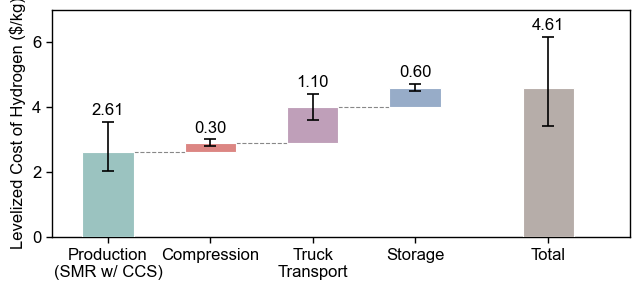

In [21]:
import matplotlib.pyplot as plt
import numpy as np

plt.rc('font', family='Arial')

# SMR w/ CCS production cost ($/kg H2)
smr_production = {'min': 2.05, 'base': 2.61, 'max': 3.54}

# Delivery cost components
compression    = {'min': 0.20, 'base': 0.30, 'max': 0.40}
transportation = {'min': 0.70, 'base': 1.10, 'max': 1.50}
storage        = {'min': 0.48, 'base': 0.60, 'max': 0.72}

steps  = [smr_production, compression, transportation, storage]
labels = ['Production\n(SMR w/ CCS)', 'Compression', 'Truck\nTransport', 'Storage']
colors = ['#9bc3c0', '#dc8683', '#bf9fb9', '#97acc8']

# Bottom of each floating bar = cumulative baseline up to that point
bottoms = [0.0]
for s in steps[:-1]:
    bottoms.append(bottoms[-1] + s['base'])

x = np.arange(len(steps))
bar_w = 0.5

fig, ax = plt.subplots(figsize=(6.5, 3))

for i, (s, b, c) in enumerate(zip(steps, bottoms, colors)):
    ax.bar(x[i], s['base'], bottom=b, color=c, width=bar_w,
           edgecolor='white', linewidth=0.8, zorder=3)
    # Error bar at top of each segment, showing uncertainty in that step's contribution
    ax.errorbar(x[i], b + s['base'],
                yerr=[[s['base'] - s['min']], [s['max'] - s['base']]],
                fmt='none', color='black', capsize=4, linewidth=1.2, capthick=1.2, zorder=4)

# Total (delivered) bar
total_base = sum(s['base'] for s in steps)
total_min  = sum(s['min']  for s in steps)
total_max  = sum(s['max']  for s in steps)

x_tot = len(steps) + 0.3
ax.bar(x_tot, total_base, bottom=0, color='#b6ada9', width=bar_w,
       edgecolor='white', linewidth=0.8, zorder=3)
ax.errorbar(x_tot, total_base,
            yerr=[[total_base - total_min], [total_max - total_base]],
            fmt='none', color='black', capsize=4, linewidth=1.2, capthick=1.2, zorder=4)

# Dashed connector lines from top of bar i to bottom of bar i+1
for i in range(len(steps) - 1):
    y_conn = bottoms[i + 1]
    ax.plot([x[i] + bar_w / 2, x[i + 1] - bar_w / 2], [y_conn, y_conn],
            color='#888888', linestyle='--', linewidth=0.8, zorder=2)

# Baseline value labels above each error bar
for i, (s, b) in enumerate(zip(steps, bottoms)):
    ax.text(x[i], b + s['max'] + 0.12, f'{s["base"]:.2f}',
            ha='center', va='bottom', fontsize=12)
ax.text(x_tot, total_max + 0.12, f'{total_base:.2f}',
        ha='center', va='bottom', fontsize=12)

all_x      = list(x) + [x_tot]
all_labels = labels + ['Total']
ax.set_xticks(all_x)
ax.set_xticklabels(all_labels, fontsize=12)
ax.set_ylabel('Levelized Cost of Hydrogen ($/kg)', fontsize=12)
ax.set_xlim(-0.55, x_tot + bar_w / 2 + 0.55)
ax.set_ylim(0, 7)

ax.tick_params(axis='both', which='major', labelsize=12, width=1, length=4)
for axis in ['left', 'bottom', 'top', 'right']:
    ax.spines[axis].set_linewidth(1.0)

# ax.grid(axis='y', linestyle='--', alpha=0.3, zorder=0)
plt.rcParams['svg.fonttype'] = 'none'
plt.tight_layout()
plt.savefig('smr_h2_waterfall.svg', dpi=500, bbox_inches='tight')
plt.show()
